<>:84: SyntaxWarning: invalid escape sequence '\O'
<>:85: SyntaxWarning: invalid escape sequence '\O'
<>:84: SyntaxWarning: invalid escape sequence '\O'
<>:85: SyntaxWarning: invalid escape sequence '\O'
C:\Users\julia\AppData\Local\Temp\ipykernel_34692\134660466.py:84: SyntaxWarning: invalid escape sequence '\O'
  ax_sch.text(0.2, 0.7, '200/500 $\Omega$', color='#4488CC', ha='right', fontsize=10) # Using dual color text is hard in one string
C:\Users\julia\AppData\Local\Temp\ipykernel_34692\134660466.py:85: SyntaxWarning: invalid escape sequence '\O'
  ax_sch.text(0.6, -0.1, '0.55/1.05 M$\Omega$', color='#4488CC', ha='center', fontsize=10)


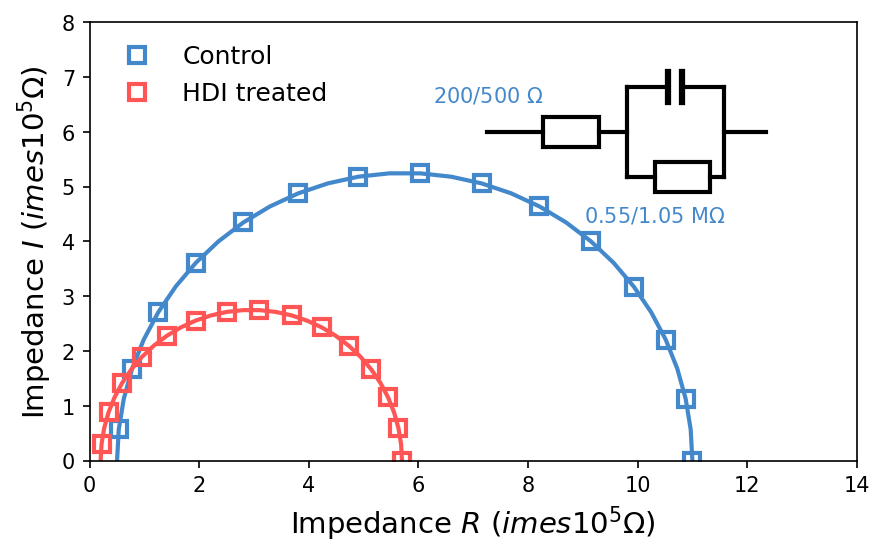

In [1]:
import matplotlib.pyplot as plt
import numpy as np


# --- Data Simulation ---
def impedance_arc(r_series, r_ct, freq):
    # Z = Rs + Rct / (1 + j*w*Rct*C)
    # Simple semi-circle: (x - center)^2 + y^2 = r^2
    # Center = Rs + Rct/2, Radius = Rct/2
    omega = 2 * np.pi * freq
    # To get a nice semi-circle shape without full complex calc, we can simulate circle directly
    # x goes from Rs to Rs+Rct
    # y = sqrt(radius^2 - (x-center)^2)
    return

# Generating points for semi-circle
def generate_semicircle(rs, rct, num_points=30):
    theta = np.linspace(0, np.pi, num_points)
    radius = rct / 2
    center = rs + radius
    x = center + radius * np.cos(theta)
    y = radius * np.sin(theta)
    return x, y

# Control (Blue): Large
x_ctrl, y_ctrl = generate_semicircle(0.5, 10.5) # x 10^5 Ohm
# Add some tail (Warburg)? No, looks like pure semi-circle touching axis
# Fits show solid lines, markers are squares

# HDI (Red): Small
x_hdi, y_hdi = generate_semicircle(0.2, 5.5)

# Markers (decimated)
x_ctrl_mk = x_ctrl[::2]
y_ctrl_mk = y_ctrl[::2]
x_hdi_mk = x_hdi[::2]
y_hdi_mk = y_hdi[::2]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Plots
# Control
ax.plot(x_ctrl, y_ctrl, '-', color='#4488CC', lw=2)
ax.plot(x_ctrl_mk, y_ctrl_mk, 's', color='#4488CC', mfc='none', markersize=8, mew=2, label='Control')

# HDI
ax.plot(x_hdi, y_hdi, '-', color='#FF5555', lw=2)
ax.plot(x_hdi_mk, y_hdi_mk, 's', color='#FF5555', mfc='none', markersize=8, mew=2, label='HDI treated')

# Styling
ax.set_xlabel(r'Impedance $R$ ($	imes 10^5 \Omega$)', fontsize=14)
ax.set_ylabel(r'Impedance $I$ ($	imes 10^5 \Omega$)', fontsize=14)
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.set_aspect('equal') # Nyquist plots should have equal aspect ratio

# Legend
ax.legend(frameon=False, loc='upper left', fontsize=12)

# Inset Schematic (Placeholder)
# Drawing simple circuit: R - (C || R)
ax_sch = ax.inset_axes([0.5, 0.6, 0.4, 0.3])
ax_sch.axis('off')
# Resistor
ax_sch.plot([0, 0.2], [0.5, 0.5], 'k-', lw=2)
ax_sch.add_patch(plt.Rectangle((0.2, 0.4), 0.2, 0.2, fc='white', ec='k', lw=2))
ax_sch.plot([0.4, 0.5], [0.5, 0.5], 'k-', lw=2)
# Split
ax_sch.plot([0.5, 0.5], [0.2, 0.8], 'k-', lw=2)
# Top C
ax_sch.plot([0.5, 0.65], [0.8, 0.8], 'k-', lw=2)
ax_sch.plot([0.65, 0.65], [0.7, 0.9], 'k-', lw=3) # Plate 1
ax_sch.plot([0.7, 0.7], [0.7, 0.9], 'k-', lw=3) # Plate 2
ax_sch.plot([0.7, 0.85], [0.8, 0.8], 'k-', lw=2)
# Bottom R
ax_sch.plot([0.5, 0.6], [0.2, 0.2], 'k-', lw=2)
ax_sch.add_patch(plt.Rectangle((0.6, 0.1), 0.2, 0.2, fc='white', ec='k', lw=2))
ax_sch.plot([0.8, 0.85], [0.2, 0.2], 'k-', lw=2)
# Join
ax_sch.plot([0.85, 0.85], [0.2, 0.8], 'k-', lw=2)
ax_sch.plot([0.85, 1.0], [0.5, 0.5], 'k-', lw=2)

# Values
ax_sch.text(0.2, 0.7, r'200/500 $\Omega$', color='#4488CC', ha='right', fontsize=10) # Using dual color text is hard in one string
ax_sch.text(0.6, -0.1, r'0.55/1.05 M$\Omega$', color='#4488CC', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
